# QAOA Ising Depth Sweep -- Analysis

Loads precomputed sweep results from `results/` (produced by
`notebooks/run_on_colab.ipynb`) and plots them. This notebook doesn't
require Colab and doesn't recompute anything. It only reads
`results/depth_sweep_results.json` (and, if present,
`results/gpu_timing_results.json`) and plots.

Main deliverable plot: `epsilon(p)` vs. `p`, per instance, with COBYLA and
L-BFGS-B as separate lines. Secondary plots: a uniform-vs-frustrated
comparison chart, restart-energy spread, function-eval/time cost, and a CPU-vs-GPU timing
comparison (if that data was generated).

In [ ]:
import json
import os
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np


def _find_repo_root(start):
    d = os.path.abspath(start)
    for _ in range(5):
        if os.path.isdir(os.path.join(d, "src")) and os.path.isfile(os.path.join(d, "requirements.txt")):
            return d
        d = os.path.dirname(d)
    raise RuntimeError(f"Could not locate qaoa-ising repo root from {start}")


REPO_ROOT = _find_repo_root(os.getcwd())
RESULTS_DIR = os.path.join(REPO_ROOT, "results")
MAIN_RESULTS_FILE = os.path.join(RESULTS_DIR, "depth_sweep_results.json")
GPU_TIMING_FILE = os.path.join(RESULTS_DIR, "gpu_timing_results.json")

print(f"REPO_ROOT = ./{os.path.basename(REPO_ROOT)}")
print(f"MAIN_RESULTS_FILE = {os.path.relpath(MAIN_RESULTS_FILE, REPO_ROOT)}")

In [2]:
with open(MAIN_RESULTS_FILE) as f:
    main_data = json.load(f)

config = main_data["config"]
records = main_data["records"]

print(f"Loaded {len(records)} records")
print("Sweep config:", json.dumps(config, indent=2))

Loaded 24 records
Sweep config: {
  "p_values": [
    1,
    2,
    3
  ],
  "n_restarts": 2,
  "optimizer_methods": [
    "COBYLA",
    "L-BFGS-B"
  ],
  "minimize_options": {
    "maxiter": 50,
    "maxfun": 60
  },
  "device": "CPU",
  "seed": 42,
  "n_spins": 6,
  "instance_names": [
    "uniform_FM",
    "frustrated",
    "with_field",
    "frustrated_pbc"
  ],
  "wall_time_s_total": 695.9218239784241
}


In [3]:
instance_names = sorted({r["instance_name"] for r in records})
optimizer_methods = sorted({r["optimizer_method"] for r in records})

# eps_by[instance][optimizer] = {p: epsilon}
eps_by = defaultdict(lambda: defaultdict(dict))
# std_by[instance][optimizer] = {p: std(restart_energies)}  -- restart-robustness proxy
std_by = defaultdict(lambda: defaultdict(dict))
# wall_by[instance][optimizer] = {p: wall_time_s}
wall_by = defaultdict(lambda: defaultdict(dict))
# fevals_by[instance][optimizer] = {p: n_function_evals_total}
fevals_by = defaultdict(lambda: defaultdict(dict))

for r in records:
    name, opt, p = r["instance_name"], r["optimizer_method"], r["p"]
    eps_by[name][opt][p] = r["epsilon"]
    std_by[name][opt][p] = float(np.std(r["restart_energies"]))
    wall_by[name][opt][p] = r["wall_time_s"]
    fevals_by[name][opt][p] = r["n_function_evals_total"]

print("Instances:", instance_names)
print("Optimizers:", optimizer_methods)

Instances: ['frustrated', 'frustrated_pbc', 'uniform_FM', 'with_field']
Optimizers: ['COBYLA', 'L-BFGS-B']


## `epsilon(p)` vs. `p`, per instance, per optimizer

The main deliverable plot: relative energy error
`epsilon(p) = (E_qaoa(p) - E_0) / |E_0|` against QAOA depth `p`, one panel
per instance, COBYLA and L-BFGS-B as separate lines. `epsilon -> 0`
means QAOA found the exact ground state energy.

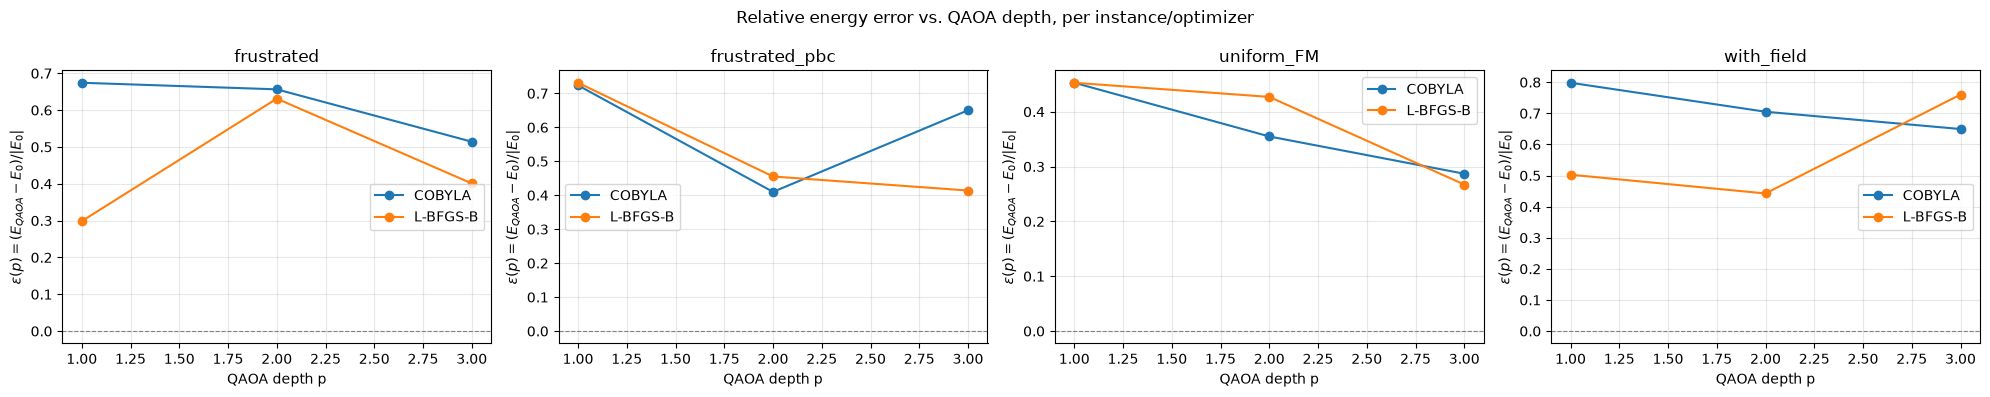

In [4]:
fig, axes = plt.subplots(1, len(instance_names), figsize=(5 * len(instance_names), 4), sharey=False)
if len(instance_names) == 1:
    axes = [axes]

for ax, name in zip(axes, instance_names):
    for opt in optimizer_methods:
        p_eps = sorted(eps_by[name][opt].items())
        ps = [p for p, _ in p_eps]
        eps = [e for _, e in p_eps]
        ax.plot(ps, eps, marker="o", label=opt)
    ax.set_title(name)
    ax.set_xlabel("QAOA depth p")
    ax.set_ylabel(r"$\epsilon(p) = (E_{QAOA} - E_0)/|E_0|$")
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle("Relative energy error vs. QAOA depth, per instance/optimizer")
fig.tight_layout()
plt.show()

## Uniform vs. frustrated comparison

Overlays `epsilon(p)` for the uniform-ferromagnetic chain (`uniform_FM`)
against the random-sign ("frustrated") chain (`frustrated`), both
optimizers on one axis.

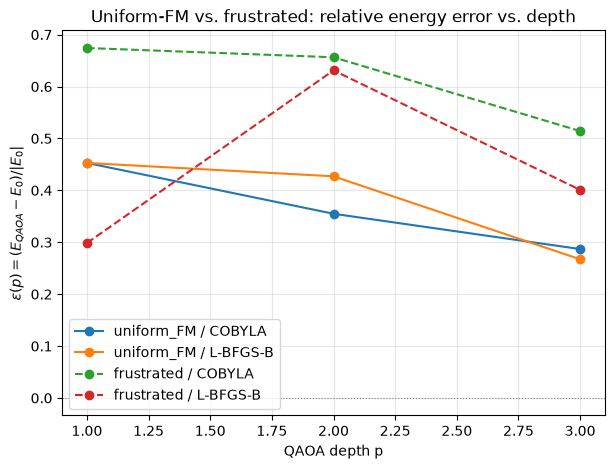

In [5]:
compare_names = [n for n in ("uniform_FM", "frustrated") if n in instance_names]

fig, ax = plt.subplots(figsize=(7, 5))
style_by_instance = {"uniform_FM": "-", "frustrated": "--"}
for name in compare_names:
    for opt in optimizer_methods:
        p_eps = sorted(eps_by[name][opt].items())
        ps = [p for p, _ in p_eps]
        eps = [e for _, e in p_eps]
        ax.plot(
            ps, eps, marker="o",
            linestyle=style_by_instance.get(name, "-"),
            label=f"{name} / {opt}",
        )

ax.set_xlabel("QAOA depth p")
ax.set_ylabel(r"$\epsilon(p) = (E_{QAOA} - E_0)/|E_0|$")
ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.set_title("Uniform-FM vs. frustrated: relative energy error vs. depth")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Restart-energy spread (optimization-landscape robustness)

Standard deviation of the `n_restarts` best-found energies at each `(p,
optimizer)` point, per instance. Frustrated (random-sign coupling) instances are
expected to show a wider restart spread than the uniform chain, since
different random restarts more easily land in different local optima.

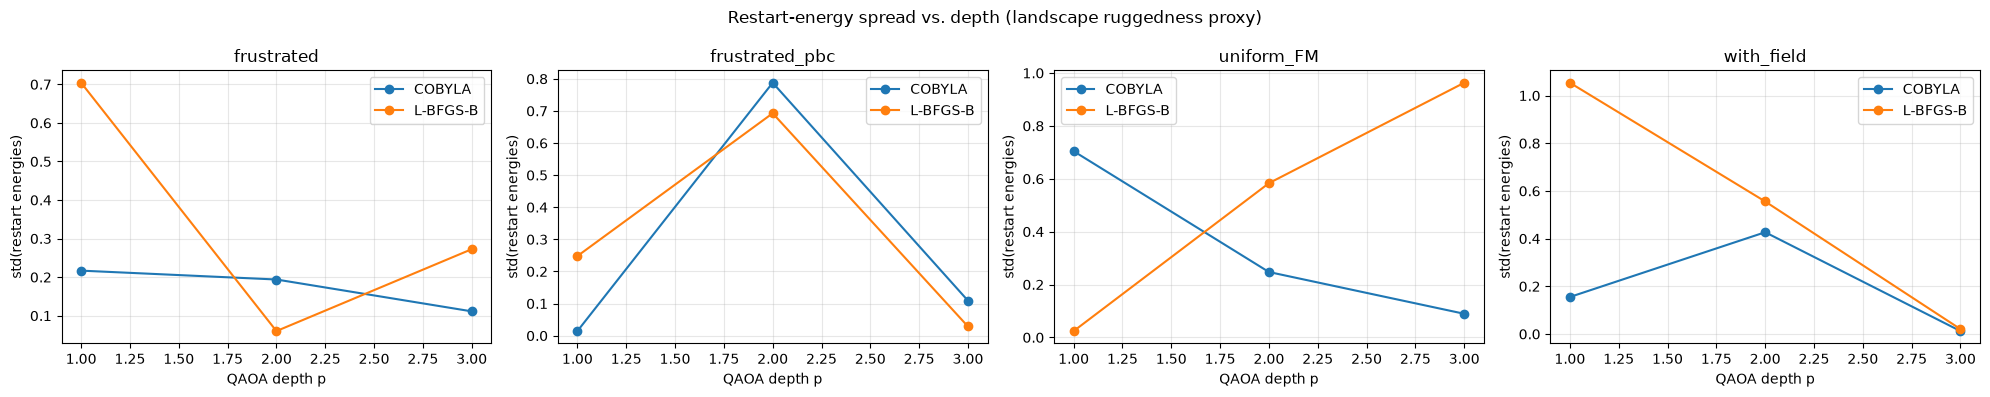

In [6]:
fig, axes = plt.subplots(1, len(instance_names), figsize=(5 * len(instance_names), 4), sharey=False)
if len(instance_names) == 1:
    axes = [axes]

for ax, name in zip(axes, instance_names):
    for opt in optimizer_methods:
        p_std = sorted(std_by[name][opt].items())
        ps = [p for p, _ in p_std]
        stds = [s for _, s in p_std]
        ax.plot(ps, stds, marker="o", label=opt)
    ax.set_title(name)
    ax.set_xlabel("QAOA depth p")
    ax.set_ylabel("std(restart energies)")
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle("Restart-energy spread vs. depth (landscape ruggedness proxy)")
fig.tight_layout()
plt.show()

## Optimization cost: wall-clock time and function evaluations

Total wall-clock time and total `scipy.optimize.minimize` function
evaluations (summed across all `n_restarts` restarts) per `(p, optimizer)`
point, per instance -- reflects that L-BFGS-B's finite-differenced gradient
costs extra circuit evaluations per iteration relative to COBYLA.

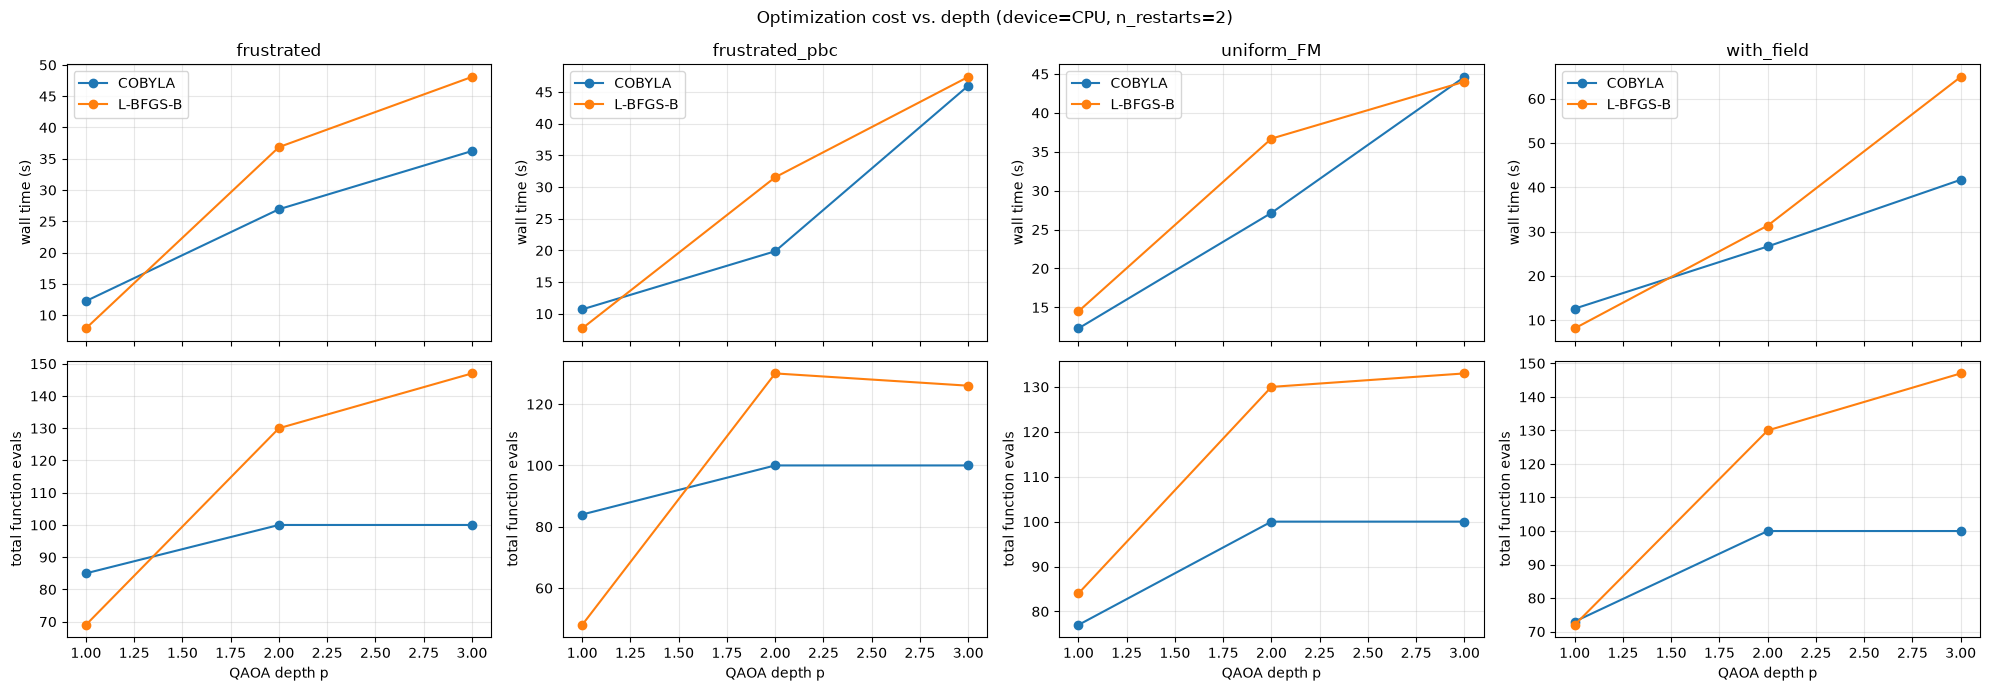

In [7]:
fig, axes = plt.subplots(2, len(instance_names), figsize=(5 * len(instance_names), 7), sharex=True)
if len(instance_names) == 1:
    axes = axes.reshape(2, 1)

for col, name in enumerate(instance_names):
    ax_wall, ax_fevals = axes[0, col], axes[1, col]
    for opt in optimizer_methods:
        p_wall = sorted(wall_by[name][opt].items())
        p_fevals = sorted(fevals_by[name][opt].items())
        ax_wall.plot([p for p, _ in p_wall], [w for _, w in p_wall], marker="o", label=opt)
        ax_fevals.plot([p for p, _ in p_fevals], [n for _, n in p_fevals], marker="o", label=opt)
    ax_wall.set_title(name)
    ax_wall.set_ylabel("wall time (s)")
    ax_fevals.set_xlabel("QAOA depth p")
    ax_fevals.set_ylabel("total function evals")
    ax_wall.legend()
    ax_wall.grid(alpha=0.3)
    ax_fevals.grid(alpha=0.3)

fig.suptitle(f"Optimization cost vs. depth (device={config.get('device', '?')}, n_restarts={config.get('n_restarts', '?')})")
fig.tight_layout()
plt.show()

## CPU vs. GPU wall-clock comparison

Loads `results/gpu_timing_results.json` if `run_on_colab.ipynb`'s optional
GPU-timing cell produced one (Colab GPU runtime + `qiskit-aer-gpu` only).
Skips gracefully with a message if that file isn't present (e.g. this
analysis is being run against a CPU-only sweep).

In [ ]:
if os.path.isfile(GPU_TIMING_FILE):
    with open(GPU_TIMING_FILE) as f:
        gpu_data = json.load(f)

    cpu_total = gpu_data["cpu_wall_time_s_total"]
    gpu_total = gpu_data["gpu_wall_time_s_total"]
    gcfg = gpu_data["config"]

    fig, ax = plt.subplots(figsize=(4, 4))
    bars = ax.bar(["CPU", "GPU"], [cpu_total, gpu_total], color=["tab:blue", "tab:orange"])
    ax.bar_label(bars, fmt="%.2fs")
    ax.set_ylabel("total wall time (s)")
    ax.set_title(
        f"CPU vs GPU wall-clock\n"
        f"(instances={gcfg['instance_names']}, p={gcfg['p_values']}, "
        f"n_restarts={gcfg['n_restarts']})"
    )
    fig.tight_layout()
    plt.show()

    speedup = cpu_total / gpu_total if gpu_total > 0 else float("nan")
    print(f"CPU total: {cpu_total:.2f}s, GPU total: {gpu_total:.2f}s, CPU/GPU ratio: {speedup:.2f}x")
else:
    print(
        f"No GPU timing file found at {os.path.relpath(GPU_TIMING_FILE, REPO_ROOT)}. Run "
        "notebooks/run_on_colab.ipynb's optional GPU-timing cell on a Colab "
        "GPU runtime (with qiskit-aer-gpu installed) to generate one -- "
        "skipping the CPU-vs-GPU comparison for this (CPU-only) results set."
    )